In [2]:
# import system libs
import os
import itertools

# import data handling tools
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# ignore the warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
train_data_dir = "C:\Desktop\ml adda\ML-adda\Brain Tumor Detection\Dataset\Training"
filepaths = []
labels = []

folds = os.listdir(train_data_dir)

for fold in folds:
    foldpath = os.path.join(train_data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        
        filepaths.append(fpath)
        labels.append(fold)

Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')

train_df = pd.concat([Fseries, Lseries], axis= 1)

In [4]:
train_df

,filepaths,labels
0,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,glioma
1,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,glioma
2,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,glioma
3,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,glioma
4,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,glioma
...,...,...
5595,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,pituitary
5596,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,pituitary
5597,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,pituitary
5598,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,pituitary


In [6]:
test_data_dir = 'C:\Desktop\ml adda\ML-adda\Brain Tumor Detection\Dataset\Testing'
filepaths = []
labels = []

folds = os.listdir(test_data_dir)

for fold in folds:
    foldpath = os.path.join(test_data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        
        filepaths.append(fpath)
        labels.append(fold)

Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')

ts_df = pd.concat([Fseries, Lseries], axis= 1)


In [7]:
ts_df

,filepaths,labels
0,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,glioma
1,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,glioma
2,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,glioma
3,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,glioma
4,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,glioma
...,...,...
1595,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,pituitary
1596,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,pituitary
1597,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,pituitary
1598,C:\Desktop\ml adda\ML-adda\Brain Tumor Detecti...,pituitary


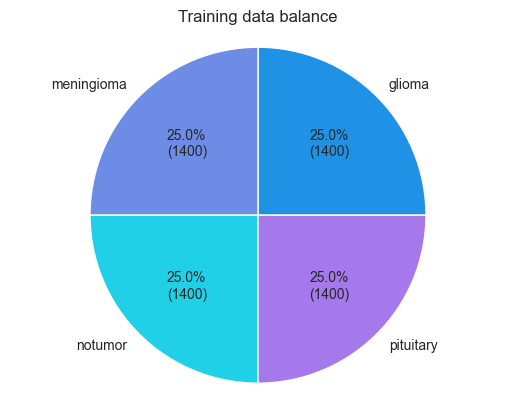

In [8]:
data_balance = train_df.labels.value_counts()


def custom_autopct(pct):
    total = sum(data_balance)
    val = int(round(pct*total/100.0))
    return "{:.1f}%\n({:d})".format(pct, val)


# pie chart for data balance
plt.pie(data_balance, labels = data_balance.index, autopct=custom_autopct, colors = ["#2092E6","#6D8CE6","#20D0E6","#A579EB"])
plt.title("Training data balance")
plt.axis("equal")
plt.show()

In [9]:
# valid and test dataframe
valid_df, test_df = train_test_split(ts_df,  train_size= 0.5, shuffle= True, random_state= 42)

In [10]:
# crobed image size
batch_size = 16
img_size = (224, 224)

tr_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
ts_gen = ImageDataGenerator(
    rescale=1./255
)
train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= batch_size)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


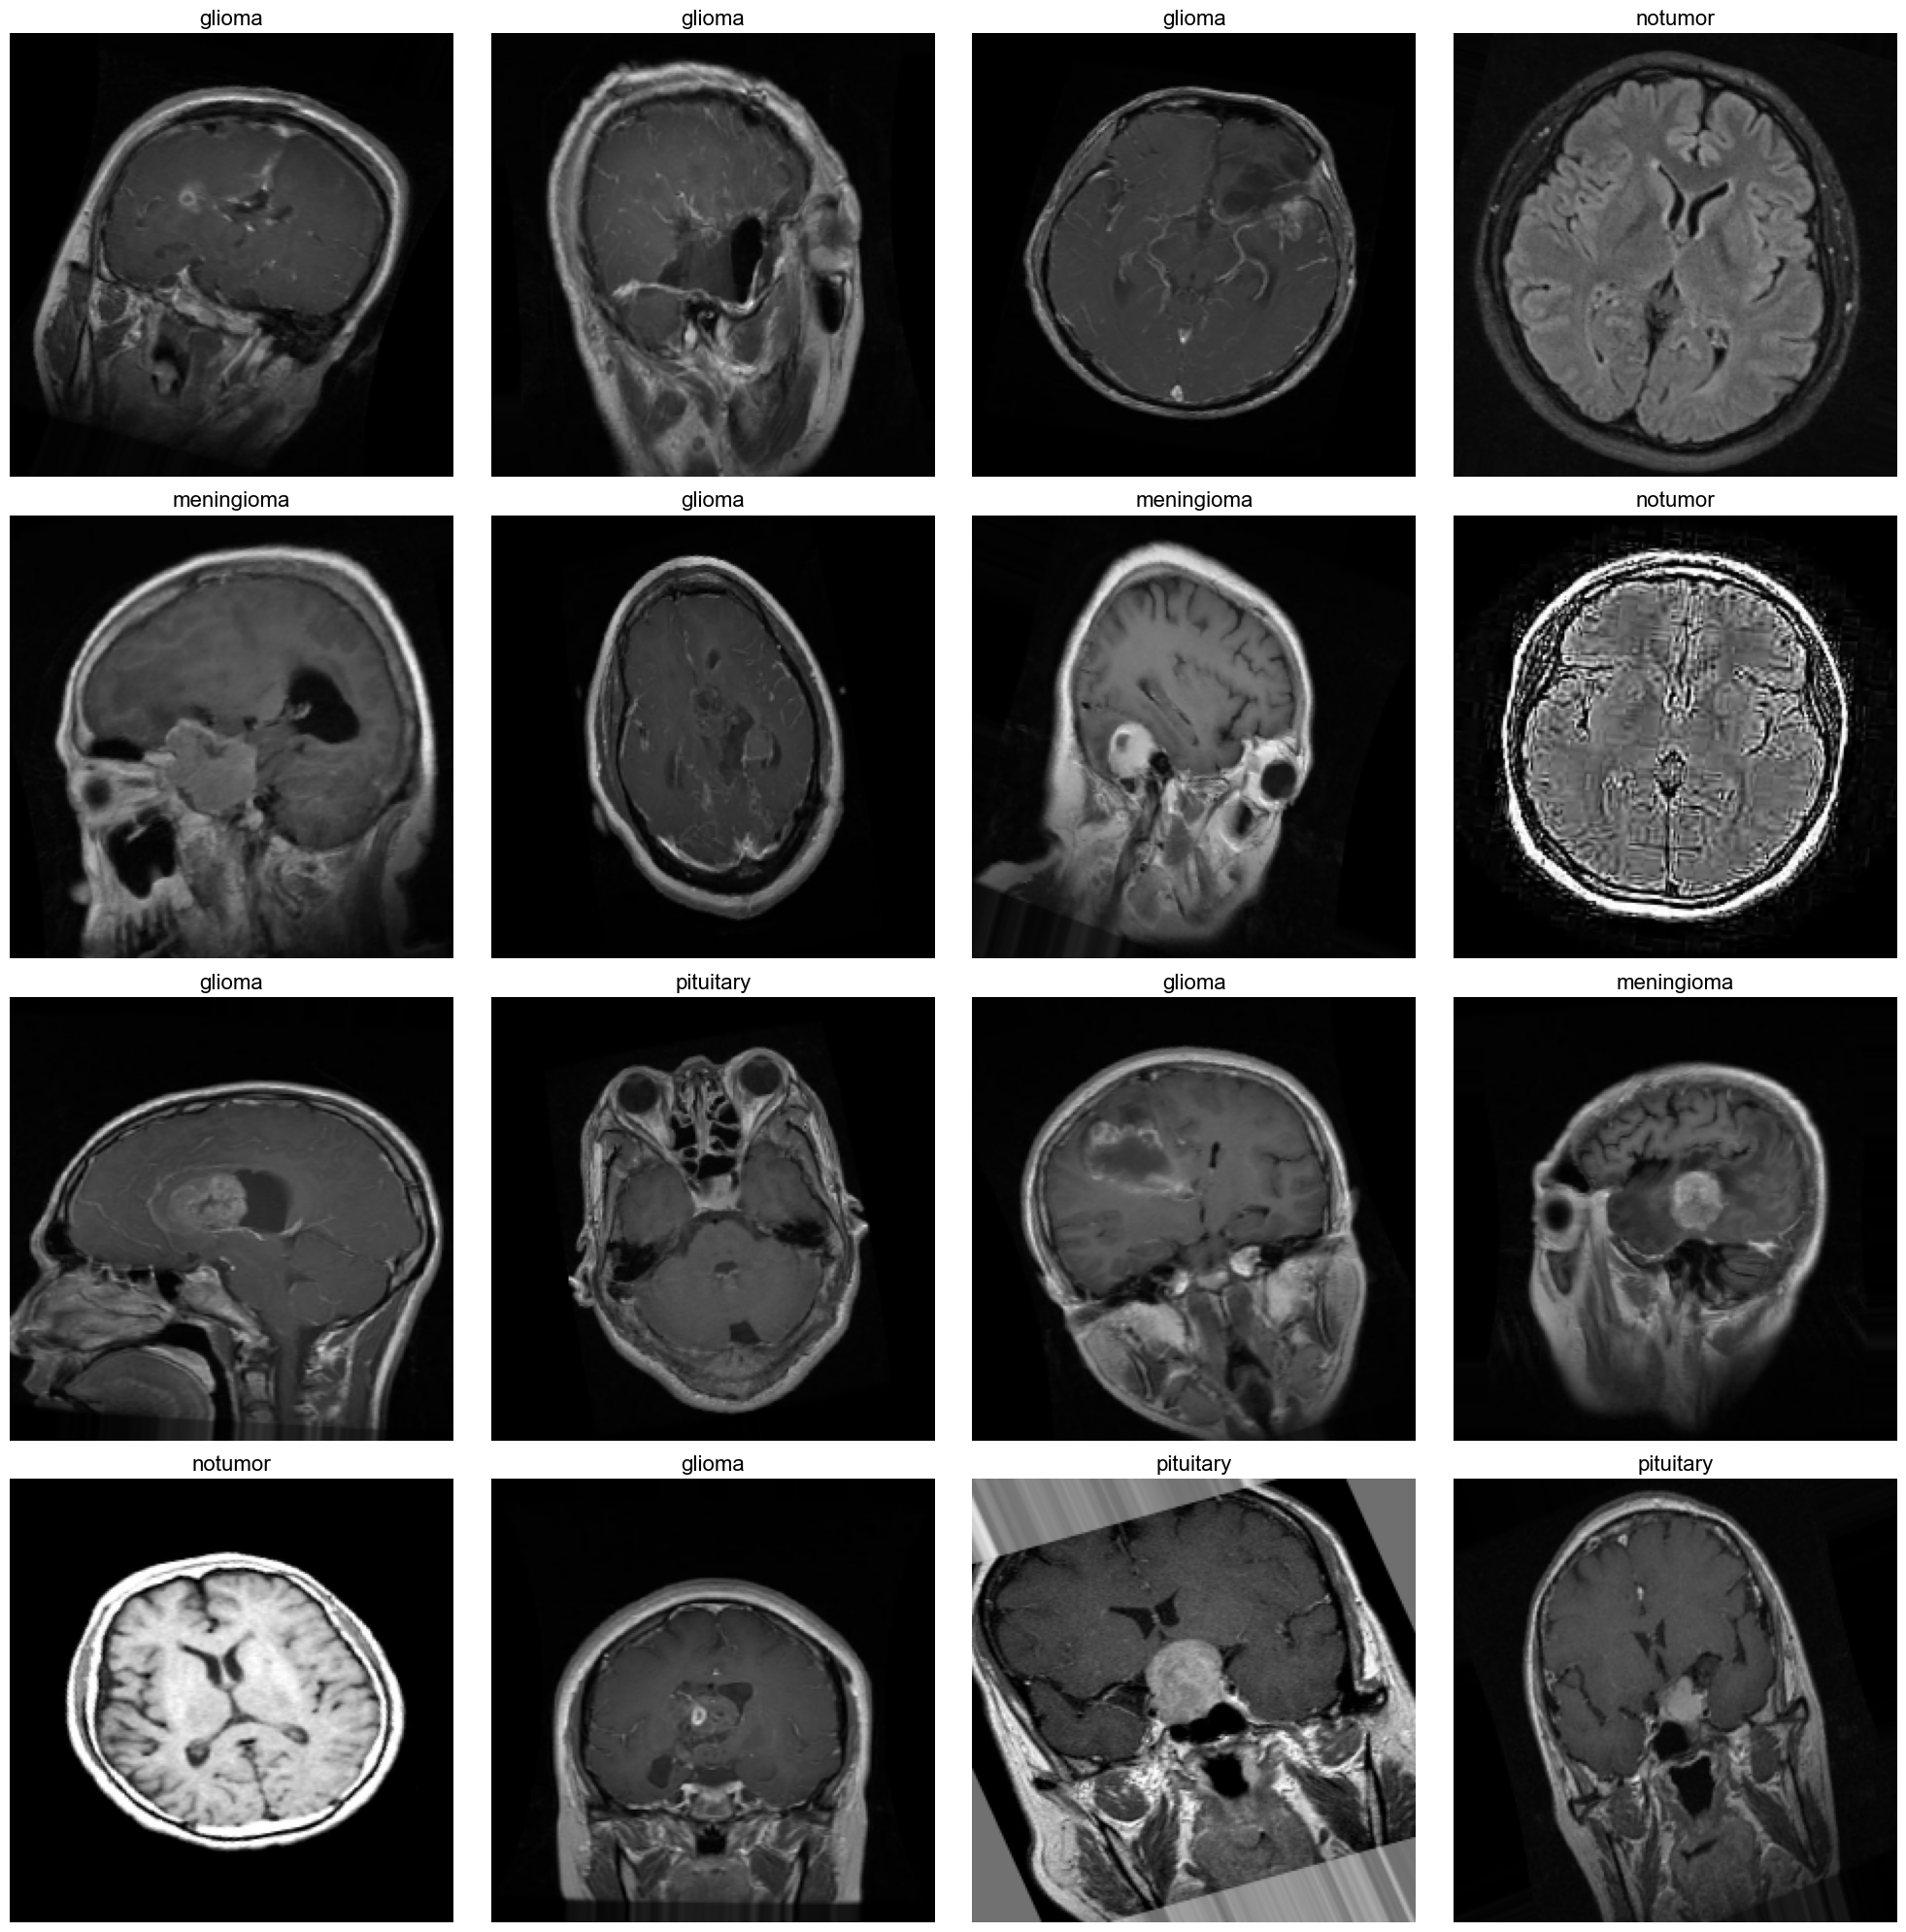

In [13]:
g_dict = train_gen.class_indices     
classes = list(g_dict.keys())     
images, labels = next(train_gen)    

plt.figure(figsize=(20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    

    image = images[i]        
    
    plt.imshow(image)
    index = np.argmax(labels[i])  
    class_name = classes[index]  
    plt.title(class_name, color='black', fontsize=16)
    plt.axis('off')
    
plt.tight_layout()
plt.show()

In [14]:

img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer

model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu", input_shape= img_shape))
model.add(MaxPooling2D())
    
model.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPooling2D())
    
model.add(Flatten())
    
model.add(Dense(64,activation = "relu"))
model.add(Dense(32,activation = "relu"))
model.add(Dense(class_count, activation = "softmax"))


In [15]:
# Compile model
model.compile(Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 56, 56, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 200704)            0         
                                                                 
 dense (Dense)               (None, 64)                1

In [16]:
epochs = 10  

history = model.fit(train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen, shuffle= False)

Epoch 1/10
350/350 [==============================] - 145s 411ms/step - loss: 0.9437 - accuracy: 0.5893 - val_loss: 1.1680 - val_accuracy: 0.6075
Epoch 2/10
350/350 [==============================] - 142s 404ms/step - loss: 0.6220 - accuracy: 0.7575 - val_loss: 0.9535 - val_accuracy: 0.7287
Epoch 3/10
350/350 [==============================] - 143s 410ms/step - loss: 0.5620 - accuracy: 0.7750 - val_loss: 1.4113 - val_accuracy: 0.6400
Epoch 4/10
350/350 [==============================] - 155s 442ms/step - loss: 0.5472 - accuracy: 0.7845 - val_loss: 1.0770 - val_accuracy: 0.7237
Epoch 5/10
350/350 [==============================] - 147s 418ms/step - loss: 0.4845 - accuracy: 0.8096 - val_loss: 1.1545 - val_accuracy: 0.7212
Epoch 6/10
350/350 [==============================] - 142s 406ms/step - loss: 0.4506 - accuracy: 0.8275 - val_loss: 1.0384 - val_accuracy: 0.7150
Epoch 7/10
350/350 [==============================] - 140s 401ms/step - loss: 0.4061 - accuracy: 0.8407 - val_loss: 1.0763 -

In [17]:
# MLP model
model2 = Sequential([
    Flatten(input_shape=img_shape),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(class_count, activation='softmax')
])

model2.compile(Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history2 = model2.fit(train_gen, epochs=epochs, verbose=1, validation_data=valid_gen, shuffle=False)

Epoch 1/10
350/350 [==============================] - 91s 258ms/step - loss: 2.4974 - accuracy: 0.4304 - val_loss: 2.4151 - val_accuracy: 0.5500
Epoch 2/10
350/350 [==============================] - 77s 219ms/step - loss: 1.5475 - accuracy: 0.4730 - val_loss: 1.2190 - val_accuracy: 0.5863
Epoch 3/10
350/350 [==============================] - 78s 223ms/step - loss: 1.3381 - accuracy: 0.4911 - val_loss: 1.6401 - val_accuracy: 0.5487
Epoch 4/10
350/350 [==============================] - 77s 221ms/step - loss: 1.2172 - accuracy: 0.5173 - val_loss: 1.1994 - val_accuracy: 0.5550
Epoch 5/10
350/350 [==============================] - 77s 221ms/step - loss: 1.1527 - accuracy: 0.5302 - val_loss: 1.0781 - val_accuracy: 0.6187
Epoch 6/10
350/350 [==============================] - 83s 237ms/step - loss: 1.0725 - accuracy: 0.5686 - val_loss: 1.0724 - val_accuracy: 0.6062
Epoch 7/10
350/350 [==============================] - 77s 220ms/step - loss: 1.0541 - accuracy: 0.5680 - val_loss: 1.1472 - val_ac

In [18]:
model2.summary()



Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 150528)            0         
                                                                 
 dense_3 (Dense)             (None, 128)               19267712  
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dense_5 (Dense)             (None, 4)                 260       
                                                                 
Total params: 19276228 (73.53 MB)
Trainable params: 19276228 (73.53 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [19]:
# Load the VGG16 model without the top (fully connected) layers
vgg_base = keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=img_shape)

# Freeze the VGG16 base model
vgg_base.trainable = False

# Create a new model on top of the VGG16 base
model3 = Sequential([
    vgg_base,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(class_count, activation='softmax')
])

model3.compile(Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history3 = model3.fit(train_gen, epochs=epochs, verbose=1, validation_data=valid_gen, shuffle=False)



58889256/58889256 [==============================] - 16s 0us/step
Epoch 1/10
350/350 [==============================] - 396s 1s/step - loss: 0.6691 - accuracy: 0.7977 - val_loss: 0.5621 - val_accuracy: 0.8037
Epoch 2/10
350/350 [==============================] - 400s 1s/step - loss: 0.3271 - accuracy: 0.8816 - val_loss: 0.5897 - val_accuracy: 0.8325
Epoch 3/10
350/350 [==============================] - 400s 1s/step - loss: 0.3035 - accuracy: 0.8870 - val_loss: 0.5028 - val_accuracy: 0.8575
Epoch 4/10
350/350 [==============================] - 388s 1s/step - loss: 0.2718 - accuracy: 0.8986 - val_loss: 0.4870 - val_accuracy: 0.8650
Epoch 5/10
350/350 [==============================] - 391s 1s/step - loss: 0.2453 - accuracy: 0.9075 - val_loss: 0.6031 - val_accuracy: 0.8388
Epoch 6/10
350/350 [==============================] - 390s 1s/step - loss: 0.2138 - accuracy: 0.9173 - val_loss: 0.7514 - val_accuracy: 0.8100
Epoch 7/10
350/350 [==============================] - 390s 1s/step - loss: 0

In [20]:
# Print model summary
model3.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten_2 (Flatten)         (None, 25088)             0         
                                                                 
 dense_6 (Dense)             (None, 256)               6422784   
                                                                 
 dense_7 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 21138500 (80.64 MB)
Trainable params: 6423812 (24.50 MB)
Non-trainable params: 14714688 (56.13 MB)
_________________________________________________________________


## Display Model Performance

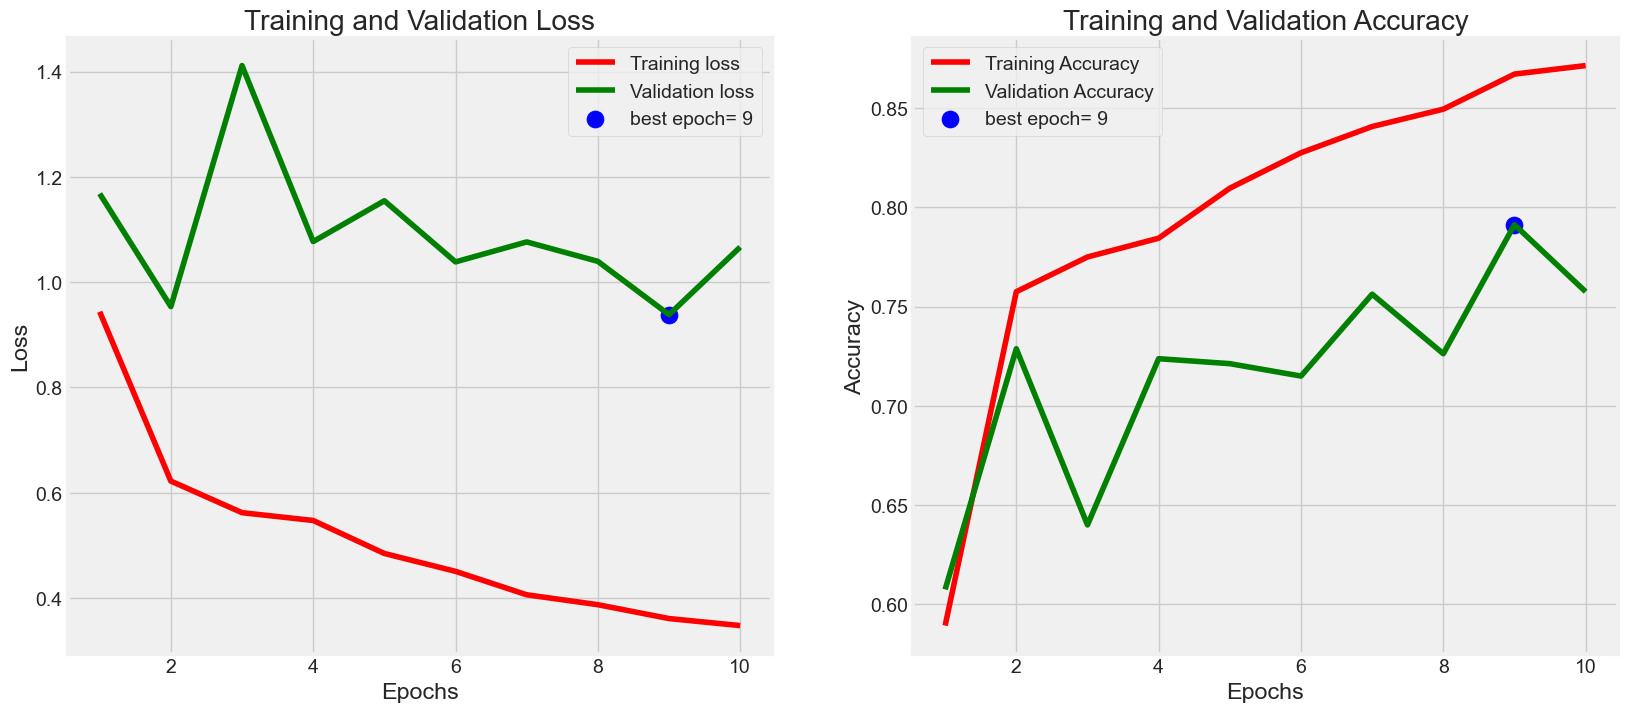

In [21]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

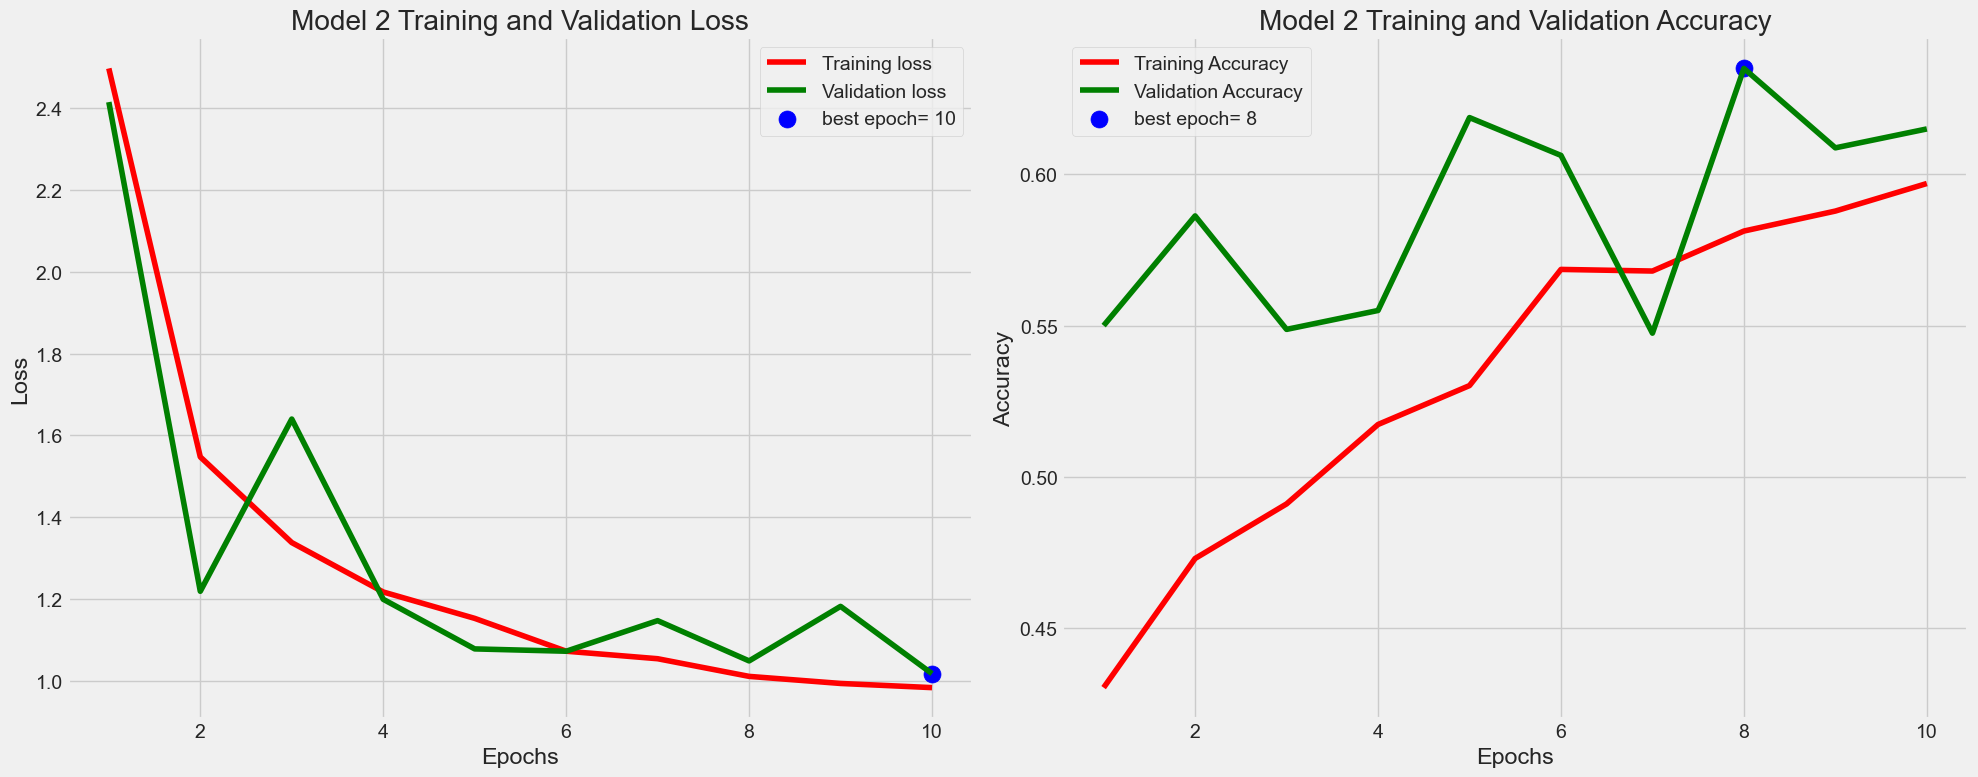

In [22]:
# Define needed variables for model2
tr_acc_model2 = history2.history['accuracy']
tr_loss_model2 = history2.history['loss']
val_acc_model2 = history2.history['val_accuracy']
val_loss_model2 = history2.history['val_loss']
index_loss_model2 = np.argmin(val_loss_model2)
val_lowest_model2 = val_loss_model2[index_loss_model2]
index_acc_model2 = np.argmax(val_acc_model2)
acc_highest_model2 = val_acc_model2[index_acc_model2]

Epochs_model2 = [i+1 for i in range(len(tr_acc_model2))]
loss_label_model2 = f'best epoch= {str(index_loss_model2 + 1)}'
acc_label_model2 = f'best epoch= {str(index_acc_model2 + 1)}'

# Plot training history for model2
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs_model2, tr_loss_model2, 'r', label='Training loss')
plt.plot(Epochs_model2, val_loss_model2, 'g', label='Validation loss')
plt.scatter(index_loss_model2 + 1, val_lowest_model2, s=150, c='blue', label=loss_label_model2)
plt.title('Model 2 Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs_model2, tr_acc_model2, 'r', label='Training Accuracy')
plt.plot(Epochs_model2, val_acc_model2, 'g', label='Validation Accuracy')
plt.scatter(index_acc_model2 + 1, acc_highest_model2, s=150, c='blue', label=acc_label_model2)
plt.title('Model 2 Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


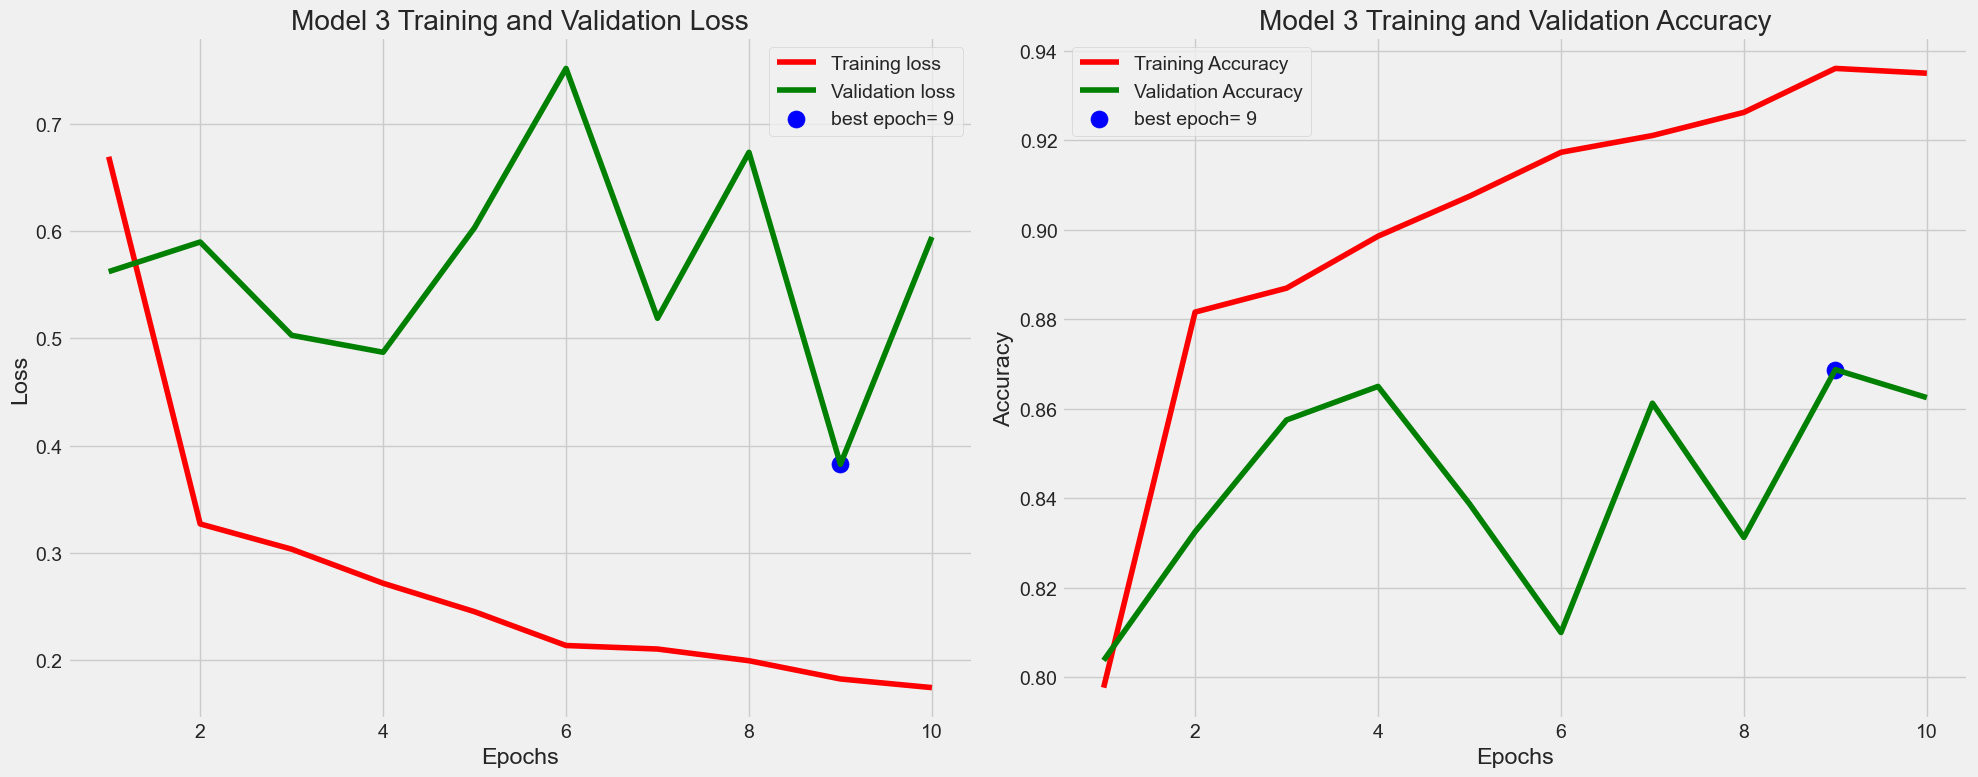

In [23]:
# Define needed variables for model3
tr_acc_model3 = history3.history['accuracy']
tr_loss_model3 = history3.history['loss']
val_acc_model3 = history3.history['val_accuracy']
val_loss_model3 = history3.history['val_loss']
index_loss_model3 = np.argmin(val_loss_model3)
val_lowest_model3 = val_loss_model3[index_loss_model3]
index_acc_model3 = np.argmax(val_acc_model3)
acc_highest_model3 = val_acc_model3[index_acc_model3]

Epochs_model3 = [i+1 for i in range(len(tr_acc_model3))]
loss_label_model3 = f'best epoch= {str(index_loss_model3 + 1)}'
acc_label_model3 = f'best epoch= {str(index_acc_model3 + 1)}'

# Plot training history for model3
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs_model3, tr_loss_model3, 'r', label='Training loss')
plt.plot(Epochs_model3, val_loss_model3, 'g', label='Validation loss')
plt.scatter(index_loss_model3 + 1, val_lowest_model3, s=150, c='blue', label=loss_label_model3)
plt.title('Model 3 Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs_model3, tr_acc_model3, 'r', label='Training Accuracy')
plt.plot(Epochs_model3, val_acc_model3, 'g', label='Validation Accuracy')
plt.scatter(index_acc_model3 + 1, acc_highest_model3, s=150, c='blue', label=acc_label_model3)
plt.title('Model 3 Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## Evaluate Model

In [24]:
##CNN
train_score = model.evaluate(train_gen, verbose= 1)
valid_score = model.evaluate(valid_gen, verbose= 1)
test_score = model.evaluate(test_gen, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

50/50 [==============================] - 4s 70ms/step - loss: 1.0496 - accuracy: 0.7563
Train Loss:  0.33819887042045593
Train Accuracy:  0.8680357336997986
--------------------
Validation Loss:  1.0665254592895508
Validation Accuracy:  0.7574999928474426
--------------------
Test Loss:  1.0495963096618652
Test Accuracy:  0.7562500238418579


In [25]:
#MLP Tensorflow
train_score_model2 = model2.evaluate(train_gen, verbose=1)
valid_score_model2 = model2.evaluate(valid_gen, verbose=1)
test_score_model2 = model2.evaluate(test_gen, verbose=1)

print("Model 2 Train Loss: ", train_score_model2[0])
print("Model 2 Train Accuracy: ", train_score_model2[1])
print('-' * 20)
print("Model 2 Validation Loss: ", valid_score_model2[0])
print("Model 2 Validation Accuracy: ", valid_score_model2[1])
print('-' * 20)
print("Model 2 Test Loss: ", test_score_model2[0])
print("Model 2 Test Accuracy: ", test_score_model2[1])


50/50 [==============================] - 1s 27ms/step - loss: 1.0483 - accuracy: 0.6150
Model 2 Train Loss:  0.951973021030426
Model 2 Train Accuracy:  0.6078571677207947
--------------------
Model 2 Validation Loss:  1.0175409317016602
Model 2 Validation Accuracy:  0.6150000095367432
--------------------
Model 2 Test Loss:  1.0482512712478638
Model 2 Test Accuracy:  0.6150000095367432


In [26]:
#VGG16
train_score_model3 = model3.evaluate(train_gen, verbose=1)
valid_score_model3 = model3.evaluate(valid_gen, verbose=1)
test_score_model3 = model3.evaluate(test_gen, verbose=1)

print("Model 3 Train Loss: ", train_score_model3[0])
print("Model 3 Train Accuracy: ", train_score_model3[1])
print('-' * 20)
print("Model 3 Validation Loss: ", valid_score_model3[0])
print("Model 3 Validation Accuracy: ", valid_score_model3[1])
print('-' * 20)
print("Model 3 Test Loss: ", test_score_model3[0])
print("Model 3 Test Accuracy: ", test_score_model3[1])


50/50 [==============================] - 48s 955ms/step - loss: 0.6636 - accuracy: 0.8413
Model 3 Train Loss:  0.14915338158607483
Model 3 Train Accuracy:  0.9446428418159485
--------------------
Model 3 Validation Loss:  0.5943698883056641
Model 3 Validation Accuracy:  0.862500011920929
--------------------
Model 3 Test Loss:  0.6636192202568054
Model 3 Test Accuracy:  0.8412500023841858


## Get Predictions

In [27]:
#CNN
preds = model.predict(test_gen)  
y_pred = np.argmax(preds, axis=1) 

50/50 [==============================] - 3s 66ms/step


In [28]:
#MLP
preds_model2 = model2.predict(test_gen)  
y_pred_model2 = np.argmax(preds_model2, axis=1) 


50/50 [==============================] - 1s 27ms/step


In [29]:
#VGG16
preds_model3 = model3.predict(test_gen)  
y_pred_model3 = np.argmax(preds_model3, axis=1) 


50/50 [==============================] - 57s 1s/step


## Confusion Matrices and Classification report

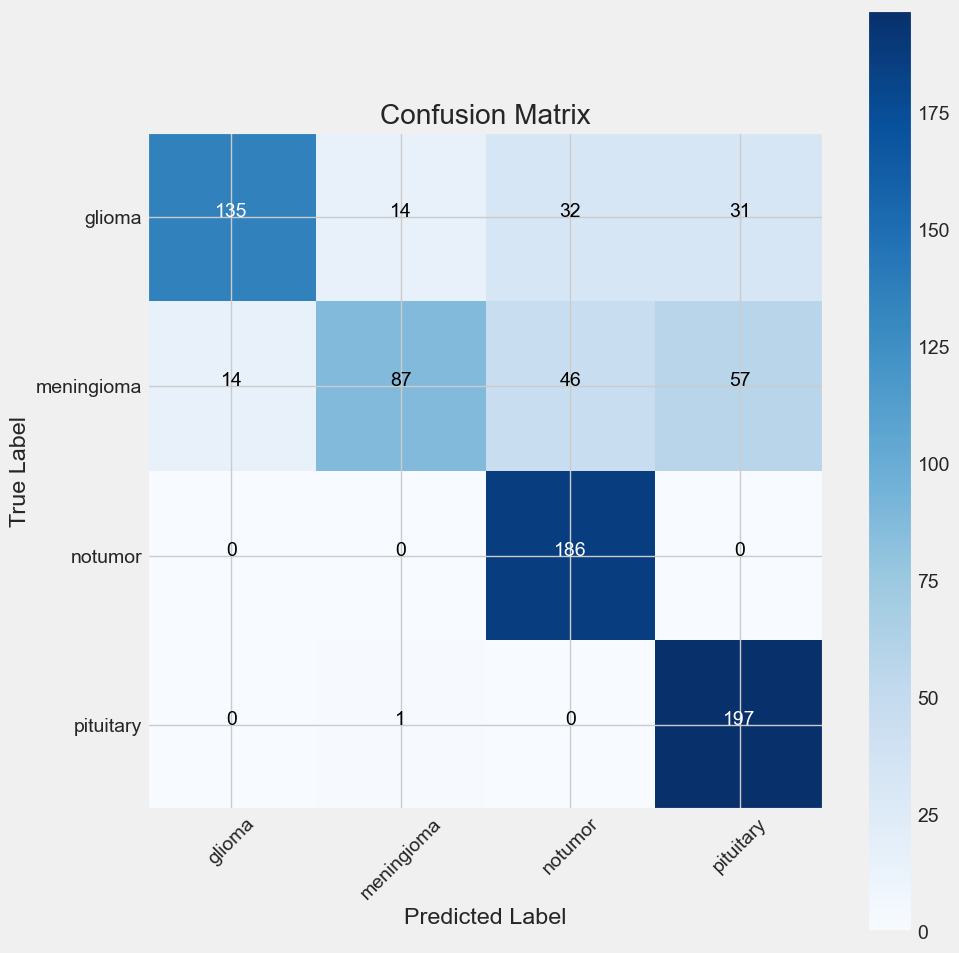

In [30]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)
cm

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')
    
    
plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

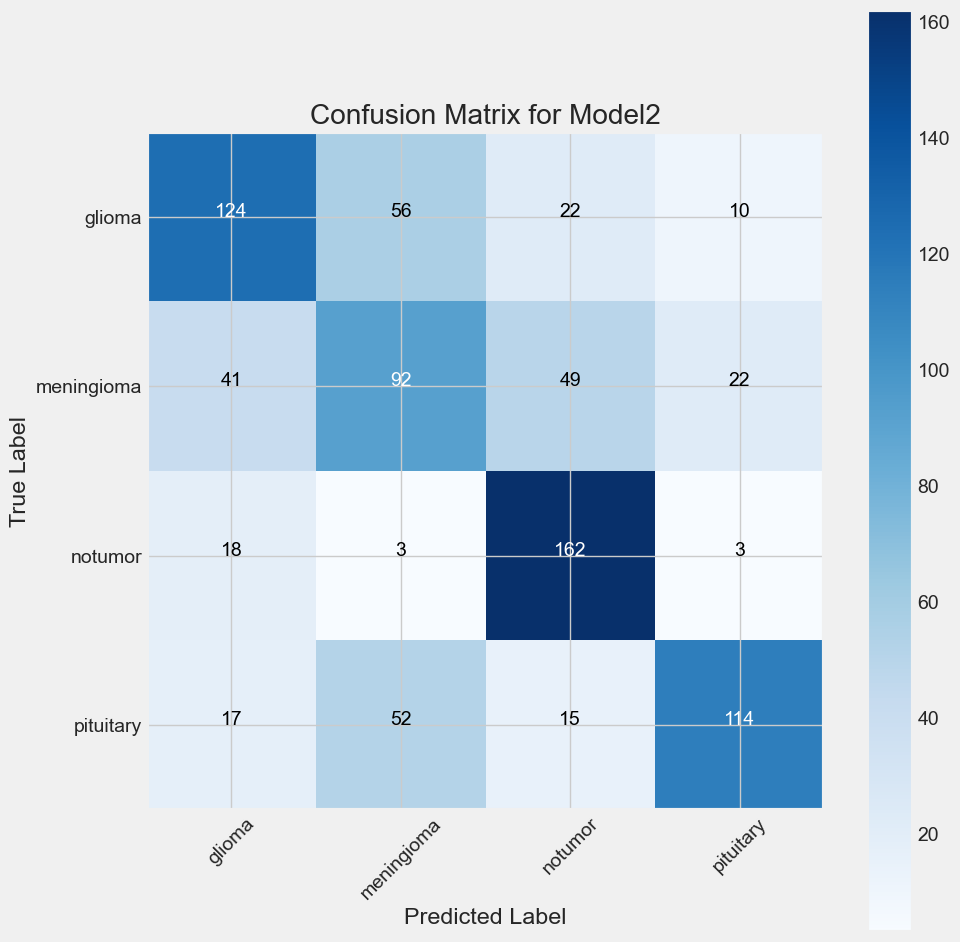

In [31]:
g_dict_model2 = test_gen.class_indices
classes_model2 = list(g_dict_model2.keys())

# Confusion matrix for model2
cm_model2 = confusion_matrix(test_gen.classes, y_pred_model2)
cm_model2

plt.figure(figsize= (10, 10))
plt.imshow(cm_model2, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix for Model2')
plt.colorbar()

tick_marks_model2 = np.arange(len(classes_model2))
plt.xticks(tick_marks_model2, classes_model2, rotation= 45)
plt.yticks(tick_marks_model2, classes_model2)

thresh_model2 = cm_model2.max() / 2.
for i, j in itertools.product(range(cm_model2.shape[0]), range(cm_model2.shape[1])):
    plt.text(j, i, cm_model2[i, j], horizontalalignment= 'center', color= 'white' if cm_model2[i, j] > thresh_model2 else 'black')
    
    
plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()


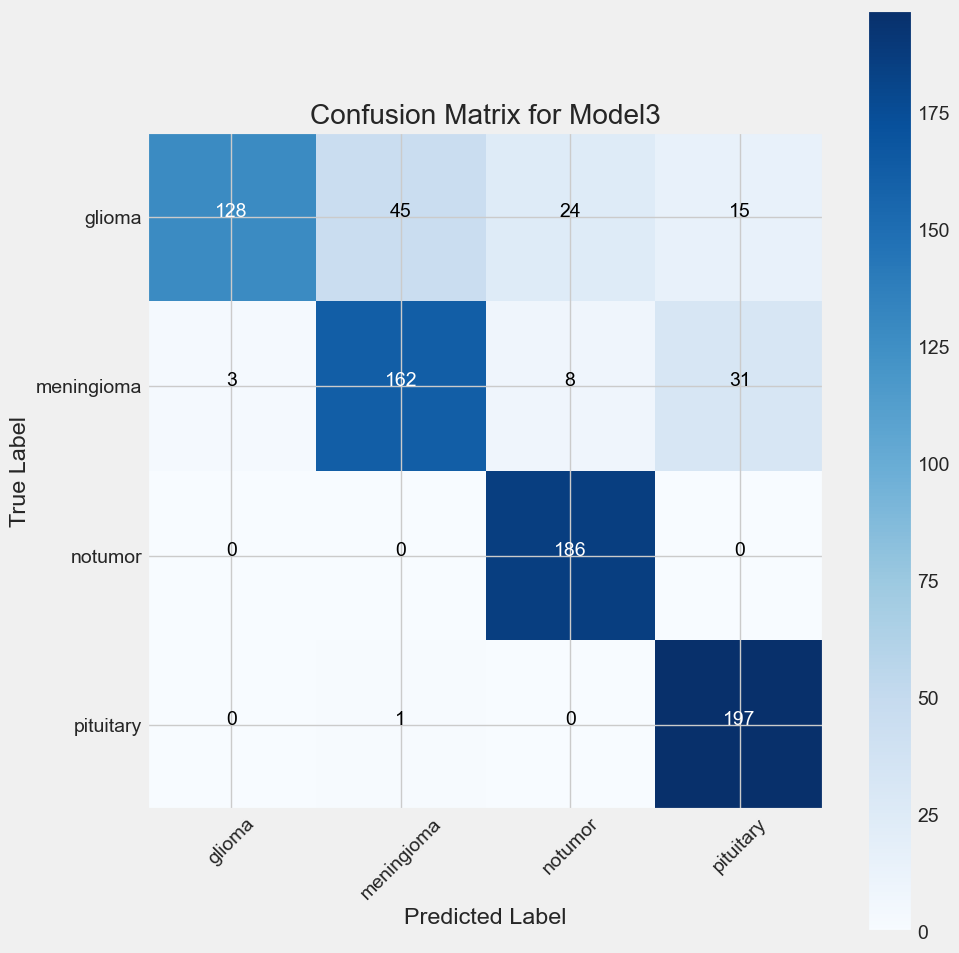

In [32]:
g_dict_model3 = test_gen.class_indices
classes_model3 = list(g_dict_model3.keys())

# Confusion matrix for model3
cm_model3 = confusion_matrix(test_gen.classes, y_pred_model3)
cm_model3

plt.figure(figsize= (10, 10))
plt.imshow(cm_model3, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix for Model3')
plt.colorbar()

tick_marks_model3 = np.arange(len(classes_model3))
plt.xticks(tick_marks_model3, classes_model3, rotation= 45)
plt.yticks(tick_marks_model3, classes_model3)

thresh_model3 = cm_model3.max() / 2.
for i, j in itertools.product(range(cm_model3.shape[0]), range(cm_model3.shape[1])):
    plt.text(j, i, cm_model3[i, j], horizontalalignment= 'center', color= 'white' if cm_model3[i, j] > thresh_model3 else 'black')
    
    
plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()


In [33]:
#CNN Classification report
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

      glioma       0.91      0.64      0.75       212
  meningioma       0.85      0.43      0.57       204
     notumor       0.70      1.00      0.83       186
   pituitary       0.69      0.99      0.82       198

    accuracy                           0.76       800
   macro avg       0.79      0.76      0.74       800
weighted avg       0.79      0.76      0.74       800



In [35]:
#MLP Classificatoin Report
print(classification_report(test_gen.classes, y_pred_model2, target_names= classes_model2))


              precision    recall  f1-score   support

      glioma       0.62      0.58      0.60       212
  meningioma       0.45      0.45      0.45       204
     notumor       0.65      0.87      0.75       186
   pituitary       0.77      0.58      0.66       198

    accuracy                           0.61       800
   macro avg       0.62      0.62      0.61       800
weighted avg       0.62      0.61      0.61       800



In [36]:
#VGG16 Classification Report
print(classification_report(test_gen.classes, y_pred_model3, target_names= classes_model3))


              precision    recall  f1-score   support

      glioma       0.98      0.60      0.75       212
  meningioma       0.78      0.79      0.79       204
     notumor       0.85      1.00      0.92       186
   pituitary       0.81      0.99      0.89       198

    accuracy                           0.84       800
   macro avg       0.85      0.85      0.84       800
weighted avg       0.86      0.84      0.83       800

